# Implementing the Shor 9-Qubit Quantum Error-Correcting Code on Amazon Braket

> This notebook provides a systematic introduction to the theoretical foundations and practical implementation of the Shor 9-qubit quantum error-correcting code (QECC). Topics covered include the fundamental differences between classical and quantum error correction, the building blocks of bit-flip and phase-flip codes, the stabilizer formalism, a complete Shor-code implementation using the Amazon Braket SDK, and an added bridge from Shor code to surface code. The final sections introduce rotated surface-code basics, Stim/PyMatching decoding, EC2-style threshold sweeps, and timing measurements for large-scale Monte Carlo experiments.


---

## 1. Introduction: From Classical to Quantum Error Correction

Before diving into the programming implementation on Amazon Braket, it is essential to clarify the necessity of quantum error correction codes and their fundamental differences from classical error correction mechanisms.

### 1.1 Classical Error Correction

In classical computing, the most intuitive fault-tolerance mechanism is the **repetition code** combined with **majority vote** logic:

- **Encoding principle**: A single bit is duplicated multiple times — for example, encoding `0` as `000`.
- **Error correction**: If a bit-flip occurs during transmission, changing the state to `001`, the system inspects all three bits and overwrites the anomalous bit with the majority value (in this case, `0`), thereby recovering the original information.

The core assumption underlying this approach is that **information can be freely copied**. However, this assumption no longer holds in the quantum domain.

### 1.2 Quantum Constraints and the Role of Entanglement

In quantum systems, classical redundancy strategies cannot be directly applied, owing to the following three fundamental physical constraints:

**The No-Cloning Theorem**

Quantum mechanics strictly prohibits the perfect copying of an arbitrary unknown quantum state. Consequently, we cannot construct redundancy protection by simply duplicating a data qubit into three copies — the classical repetition code strategy fails entirely.

**Entanglement as the Solution**

Since quantum states cannot be "copied," quantum error-correcting codes instead exploit **quantum entanglement**: rather than duplicating the state itself, the information of a single **logical qubit** is distributed across multiple **physical qubits** through entanglement operations.

**Measurement-Induced State Collapse**

In classical systems, bit values can be read at any time without affecting the data. In quantum systems, however, direct measurement causes the superposition and entangled states to irreversibly **collapse**, thereby destroying the quantum information in the computation. Quantum error correction must extract information about "error type and location" — the so-called **syndrome measurement** — without reading the data itself.

The following equation demonstrates how a quantum state is expanded across multiple qubits through entanglement encoding. Note that this result is **not** the tensor product of three independent qubits, but rather forms an inseparable entangled state:

$$|\psi\rangle = \alpha |0\rangle + \beta |1\rangle \rightarrow |\psi_L\rangle = \alpha |000\rangle + \beta |111\rangle \neq |\psi\rangle \otimes |\psi\rangle \otimes |\psi\rangle$$

### 1.3 Quantum Error Types

Classical bits have only one error mode (`0` ↔ `1`). Quantum bits, however, possess two degrees of freedom — amplitude and phase — giving rise to a richer set of error types. These errors are typically described using the **Pauli matrices**:

- **Bit-flip (Pauli-$X$)**: Analogous to classical errors, $|0\rangle \leftrightarrow |1\rangle$.
- **Phase-flip (Pauli-$Z$)**: Preserves the probability amplitudes in the computational basis but alters the relative phase, e.g., $\alpha|0\rangle + \beta|1\rangle \rightarrow \alpha|0\rangle - \beta|1\rangle$.
- **Combined flip (Pauli-$Y$)**: Equivalent to applying both a bit-flip and a phase-flip simultaneously (with a global phase factor $i$), i.e., $Y = iXZ$.

> **Key significance**: The historical importance of the Shor 9-qubit code lies in being the first code proven capable of **simultaneously correcting bit-flip errors, phase-flip errors, and any their combination**.

---

## 2. Core Building Blocks: Bit-Flip and Phase-Flip Codes

The Shor 9-qubit code is fundamentally a **concatenated code**, constructed by nesting two independent 3-qubit codes. Before building the full Shor code, it is necessary to understand its two pillars: the bit-flip code against Pauli-$X$ errors and the phase-flip code against Pauli-$Z$ errors. The following example circuits demonstrate the logic of quantum errors and their correction.

### 2.1 The 3-Qubit Bit-Flip Code

This example circuit demonstrates how to use entanglement to protect quantum information against bit-flip errors.

**Encoding**: The data qubit $q_0$ is first set to the desired initial state. Two CNOT gates then entangle and expand $q_0$'s quantum state onto $q_1$ and $q_2$, forming the logical encoded state $|\psi_L\rangle = \alpha|000\rangle + \beta|111\rangle$.

**Error Injection**: A noise model — for example, an $X$ gate applied with random probability — simulates environmental noise inducing an unintended bit-flip on $q_0$.

**Syndrome Extraction and Parity Check**: This step is the crux of the error-correcting code. To locate errors **without measuring the data qubits**, we introduce **ancilla qubits** $a_0$, $a_1$. Through a series of CNOT gates, the parity between adjacent data qubits — whether they share the same computational basis state — is mapped onto the ancilla qubits. Specifically, $a_0$ encodes the parity of $q_0$ and $q_1$; $a_1$ encodes the parity of $q_1$ and $q_2$.

**Measurement and Decoding**: The binary results obtained from measuring the ancilla qubits (e.g., `01`, `10`, `11`) constitute the **syndrome**. A lookup table can then precisely locate the flipped data qubit, and a corresponding $X$ gate is applied to complete the correction.

In [1]:
from braket.circuits import Circuit

# Build the quantum circuit
# Qubits 0, 1, 2: Data Qubits
# Qubits 3, 4: Ancilla Qubits
circ = Circuit()

# --- Step 1: State Preparation & Encoding ---
circ.h(0)
circ.cnot(control=0, target=1)
circ.cnot(control=0, target=2)

# --- Step 2: Error Injection ---
circ.x(0)

# --- Step 3: Syndrome Extraction ---
circ.cnot(control=0, target=3)
circ.cnot(control=1, target=3)
circ.cnot(control=1, target=4)
circ.cnot(control=2, target=4)

# Note: Braket automatically measures all qubits upon task submission.

print("Quantum Circuit Diagram:")
print(circ)

Quantum Circuit Diagram:
T  : │  0  │  1  │  2  │  3  │  4  │  5  │  6  │  7  │
      ┌───┐             ┌───┐                         
q0 : ─┤ H ├───●─────●───┤ X ├───●─────────────────────
      └───┘   │     │   └───┘   │                     
            ┌─┴─┐   │           │                     
q1 : ───────┤ X ├───┼───────────┼─────●─────●─────────
            └───┘   │           │     │     │         
                  ┌─┴─┐         │     │     │         
q2 : ─────────────┤ X ├─────────┼─────┼─────┼─────●───
                  └───┘         │     │     │     │   
                              ┌─┴─┐ ┌─┴─┐   │     │   
q3 : ─────────────────────────┤ X ├─┤ X ├───┼─────┼───
                              └───┘ └───┘   │     │   
                                          ┌─┴─┐ ┌─┴─┐ 
q4 : ─────────────────────────────────────┤ X ├─┤ X ├─
                                          └───┘ └───┘ 
T  : │  0  │  1  │  2  │  3  │  4  │  5  │  6  │  7  │


### 2.2 The 3-Qubit Phase-Flip Code

Phase-flip (Pauli-$Z$) errors cannot be directly detected via the parity check described above when working in the standard computational basis ($Z$-basis). However, quantum mechanics provides an elegant equivalence: **a phase-flip in the Hadamard basis ($X$-basis, i.e., $|+\rangle$ and $|-\rangle$) is equivalent to a bit-flip in the standard basis.**

**Encoding and Basis Change**: After the CNOT entanglement expansion, Hadamard gates ($H$) are applied to all data qubits $q_0, q_1, q_2$, transforming the logical state into the $X$-basis: $|\psi_L\rangle = \alpha|{+}{+}{+}\rangle + \beta|{-}{-}{-}\rangle$.

**$Z$ Error Injection**: A $Z$ gate simulates a phase-flip error acting on $q_0$.

**Basis Rotation Back to $Z$-basis**: Before performing the parity check, Hadamard gates are applied again to the three data qubits, rotating the state back to the computational basis. After this transformation, **the original $Z$ error has been equivalently converted into an $X$ error**.

**Syndrome Extraction**: Since the error has been transformed into a bit-flip, the same parity check mechanism from §2.1 can be applied directly, using ancilla qubits $a_0, a_1$ to locate the error.

> **Design intuition behind the Shor code**: The core architecture of the Shor 9-qubit code nests — or **concatenates** — the two protection mechanisms described above. Three phase-flip code blocks form the outer layer of protection, while each block internally executes a bit-flip code as the inner layer. This is discussed fully in Part IV.

---

## 3. The Stabilizer Formalism

As quantum error correction codes scale up, tracking the full state vector becomes inefficient because the Hilbert space grows exponentially with the number of qubits. The Shor code already illustrates this challenge: its full implementation uses 9 data qubits and 8 ancilla qubits.

The **stabilizer formalism** gives a more scalable viewpoint. Rather than describing every amplitude of the quantum state, it describes the operators that define and preserve the encoded subspace. This is exactly what error correction needs: stabilizers specify the code, produce syndrome measurements, and translate physical errors into classical information that can be decoded.

### 3.1 Core Concept: From State Description to Operator Description

The key conceptual shift in the stabilizer formalism is this: rather than asking "What is the current quantum state $|\psi\rangle$?", we ask instead: **"Which operators leave this state unchanged (i.e., stabilize it)?"**

If an operator $S$ satisfies $S|\psi\rangle = +1 \cdot |\psi\rangle$, then $S$ is called a **stabilizer** of that state. For a protected logical quantum state, we need only track its stabilizer group to fully describe the code space, without processing exponentially growing state vectors.

### 3.2 Non-Destructive Measurement

To avoid destroying the superposition and entanglement in the data qubits, we use **ancilla qubits** to indirectly extract error syndromes.

Specifically, controlled gates (such as `CZ` or `CNOT`) couple the data qubits with ancilla qubits in such a way that the system's quantum information does not leak. Through non-destructive probe measurements, the eigenvalue of the stabilizer is transferred onto the ancilla qubit. Subsequent measurement of the ancilla then yields the syndrome, while the data qubits' quantum state remains intact.

### 3.3 Error Detection via Anti-Commutation

Whether an error can be detected depends on the commutation relation between the error operator $E$ and the stabilizer operator $S$:

- **Commute**: If $ES = SE$, this indicates either no error has occurred, or the error lies outside the detection range of that stabilizer. The ancilla measurement eigenvalue remains $+1$ (i.e., measurement outcome `0`).
- **Anti-commute**: If $ES = -SE$, the error pushes the quantum state from the original code space into an orthogonal error subspace. The ancilla measurement eigenvalue flips from $+1$ to $-1$ (i.e., measurement outcome `1`).

These eigenvalues are precisely encoded as readable classical bits `0` and `1`, forming the mathematical essence of the error syndrome.

### 3.4 Worked Example: 3-Qubit Bit-Flip Code with a Noise Model

To put the stabilizer formalism into practice, the following demonstrates how to use the **Amazon Braket SDK to construct a 3-qubit bit-flip code with probabilistic noise**. This implementation uses two ancilla qubits to measure stabilizers $Z_0Z_1$ and $Z_1Z_2$.

#### Introducing Noise

**Gate-level noise** means inserting noise instructions directly into the circuit, for example `qc.bit_flip(i, probability=p_error)`. This is useful for teaching because students can see exactly where the noise channel is placed.

**Global `NoiseModel`** means keeping the quantum circuit clean, then defining a separate noise environment that is applied to selected gates. This is useful when the same clean circuit should be tested under several noise assumptions.

Both approaches require a density-matrix noise simulator. In Braket, that means either:

- `LocalSimulator("braket_dm")`: local, safe for small classroom examples.
- AWS `DM1`: cloud density-matrix simulator, useful for larger noisy circuits such as the 17-qubit Shor demo.

**global `NoiseModel` can be used with both local `braket_dm` and cloud DM1**, but in this notebook we run it locally by default and keep DM1 optional because DM1 submits an AWS task and may incur cost.


In [ ]:
# Gate-level noise: insert bit_flip directly into a circuit.
# This cell only builds and prints the noisy circuit; it does not run a simulator.
from braket.circuits import Circuit

qc_gate_noise = Circuit()
qc_gate_noise.cnot(0, 1).cnot(0, 2)

p_error = 0.20
for i in range(3):
    qc_gate_noise.bit_flip(i, probability=p_error)

qc_gate_noise.cnot(0, 3).cnot(1, 3)
qc_gate_noise.cnot(1, 4).cnot(2, 4)

print(qc_gate_noise)

**Global `NoiseModel`**: A global noise model separates the clean circuit from the noise rules. In the Braket SDK version used here, the cleanest pattern is to attach the noise model when constructing the device:

```python
LocalSimulator("braket_dm", noise_model=my_noise_model)
AwsDevice("arn:aws:braket:::device/quantum-simulator/amazon/dm1", noise_model=my_noise_model)
```

Use local `braket_dm` first for a quick check. Switch to DM1 only when the circuit is too large or when you intentionally want a managed cloud simulator run.


<div class="alert alert-block alert-success">
<b>Activity: Global NoiseModel on local braket_dm; optional DM1</b>

Run the next cell as-is to execute a small clean circuit with a global `NoiseModel` on the local density-matrix simulator `braket_dm`. To submit the same clean circuit to cloud DM1, set `RUN_DM1_NOISE_MODEL_DEMO = True`; that may take time and may incur AWS cost.
</div>


In [ ]:
from braket.aws import AwsDevice
from braket.circuits import Circuit, Gate, Noise
from braket.circuits.noise_model import GateCriteria, NoiseModel
from braket.devices import LocalSimulator

RUN_LOCAL_NOISE_MODEL_DEMO = True
RUN_DM1_NOISE_MODEL_DEMO = False

# 1. Keep the circuit clean: no noise instructions are inserted here.
clean_qc = Circuit().h(0).cnot(0, 1)

# 2. Define the noise environment separately.
my_noise_model = NoiseModel()

# Rule A: gates named H or X receive a 10% bit-flip channel.
# For this demo circuit, H is the relevant single-qubit gate.
my_noise_model.add_noise(
    Noise.BitFlip(probability=0.1),
    GateCriteria(gates=[Gate.H, Gate.X]),
)

# Rule B: CNOT gates receive a 5% two-qubit depolarizing channel.
my_noise_model.add_noise(
    Noise.Depolarizing(probability=0.05),
    GateCriteria(gates=Gate.CNot),
)

print("Clean circuit:")
print(clean_qc)
print()
print("Global noise model:")
print(my_noise_model)

if RUN_LOCAL_NOISE_MODEL_DEMO:
    local_device = LocalSimulator("braket_dm", noise_model=my_noise_model)
    local_task = local_device.run(clean_qc, shots=100)
    local_result = local_task.result()
    print()
    print("Local braket_dm measurement counts:")
    print(local_result.measurement_counts)

if RUN_DM1_NOISE_MODEL_DEMO:
    dm1_device = AwsDevice(
        "arn:aws:braket:::device/quantum-simulator/amazon/dm1",
        noise_model=my_noise_model,
    )
    dm1_task = dm1_device.run(clean_qc, shots=1000)
    print(f"Submitted DM1 task ARN: {dm1_task.id}")
else:
    print()
    print("DM1 submission skipped. Set RUN_DM1_NOISE_MODEL_DEMO = True to submit to AWS DM1.")


> **Technical Note: Why use `braket_dm` or DM1 for noise?**
>
> Noise channels such as bit-flip, depolarizing, and measurement error generally transform pure states into mixed states. A density-matrix simulator is designed for this. In Braket, `LocalSimulator("braket_dm")` is the local density-matrix simulator for small noisy circuits, while DM1 is the managed cloud density-matrix simulator. Use `braket_dm` for quick local teaching examples; use DM1 when the noisy circuit is too large for the local density-matrix backend or when you need a managed AWS simulator run.


<div class="alert alert-block alert-success">
<b>Activity: Complete Executable Code: 3-Qubit Bit-Flip Code with gate-level Noise</b>

Read the note below, then run the following code cell. You can change `LOGICAL_INPUT`, `p_error`, or `shots` to observe how the 3-qubit bit-flip code diagnoses and corrects errors. This activity uses the local density-matrix simulator, so it is safe for classroom execution.
</div>


> Note: an `X` gate at the beginning is **not part of the encoding itself**. Braket qubits start in $|0\rangle$ by default. Add `X` on qubit 0 only when you want to prepare $|1\rangle$ before encoding, i.e. when the target logical state is $|1\rangle_L$. If the target logical state is $|0\rangle_L$, leave qubit 0 unchanged.


In [13]:
from braket.circuits import Circuit, Noise
from braket.devices import LocalSimulator

# =============================================
# 1. Initialize Circuit and Encoding (3-Qubit Bit-Flip Code)
# =============================================
LOGICAL_INPUT = "1"  # choose "0" or "1"

qc = Circuit()

if LOGICAL_INPUT == "1":
    qc.x(0)
elif LOGICAL_INPUT != "0":
    pass

qc.cnot(0, 1).cnot(0, 2)

# =============================================
# 2. Inject Probabilistic Noise (Noise Model)
# =============================================
p_error = 0.20
for i in range(3):
    qc.bit_flip(i, probability=p_error)

# =============================================
# 3. Syndrome Extraction
# =============================================
qc.cnot(0, 3).cnot(1, 3)  # Stabilizer Z0Z1 -> q3
qc.cnot(1, 4).cnot(2, 4)  # Stabilizer Z1Z2 -> q4

# =============================================
# 4. Execute on Local Density Matrix Simulator
# =============================================
device = LocalSimulator("braket_dm")

print("--- Starting 3-Qubit Bit-Flip Code Simulation ---")
task = device.run(qc, shots=5)
result = task.result()

for i, bitstring in enumerate(result.measurements):
    bitstring_list = list(bitstring)
    data_bits = bitstring_list[0:3]
    syn_z = bitstring_list[3:5]

    print(f"\n[Shot {i+1}]")
    print(f"  Measurement (q0, q1, q2): {data_bits}")
    print(f"  Syndrome    (q3, q4):     {syn_z}")

    if syn_z == [0, 0]:
        print("  >> Diagnosis: No error (or uncorrectable multi-qubit error)")
        corrected = data_bits
    elif syn_z == [1, 0]:
        print("  >> Diagnosis: q0 error -> applying bit-flip correction")
        corrected = [data_bits[0]^1, data_bits[1], data_bits[2]]
    elif syn_z == [0, 1]:
        print("  >> Diagnosis: q2 error -> applying bit-flip correction")
        corrected = [data_bits[0], data_bits[1], data_bits[2]^1]
    elif syn_z == [1, 1]:
        print("  >> Diagnosis: q1 error -> applying bit-flip correction")
        corrected = [data_bits[0], data_bits[1]^1, data_bits[2]]

    if syn_z != [0, 0]:
        print(f"  >> Corrected data: {corrected}")

--- Starting 3-Qubit Bit-Flip Code Simulation ---

[Shot 1]
  Measurement (q0, q1, q2): [np.int64(1), np.int64(1), np.int64(1)]
  Syndrome    (q3, q4):     [np.int64(0), np.int64(0)]
  >> Diagnosis: No error (or uncorrectable multi-qubit error)

[Shot 2]
  Measurement (q0, q1, q2): [np.int64(1), np.int64(1), np.int64(0)]
  Syndrome    (q3, q4):     [np.int64(0), np.int64(1)]
  >> Diagnosis: q2 error -> applying bit-flip correction
  >> Corrected data: [np.int64(1), np.int64(1), np.int64(1)]

[Shot 3]
  Measurement (q0, q1, q2): [np.int64(1), np.int64(0), np.int64(1)]
  Syndrome    (q3, q4):     [np.int64(1), np.int64(1)]
  >> Diagnosis: q1 error -> applying bit-flip correction
  >> Corrected data: [np.int64(1), np.int64(1), np.int64(1)]

[Shot 4]
  Measurement (q0, q1, q2): [np.int64(0), np.int64(1), np.int64(1)]
  Syndrome    (q3, q4):     [np.int64(1), np.int64(0)]
  >> Diagnosis: q0 error -> applying bit-flip correction
  >> Corrected data: [np.int64(1), np.int64(1), np.int64(1)]

[

<div class="alert alert-block alert-success">
<b>Activity: Statistical Visualization: Pre- vs. Post-Correction Measurement Distributions</b>

Run the next cell after the 3-qubit bit-flip simulation cell has produced `qc` and `device`. Try changing the `shots=1000` value to see how the histogram stabilizes with more samples. This uses the local density-matrix simulator from the previous activity, so it is safe for classroom execution.
</div>


--- Running 1000-shot simulation ---


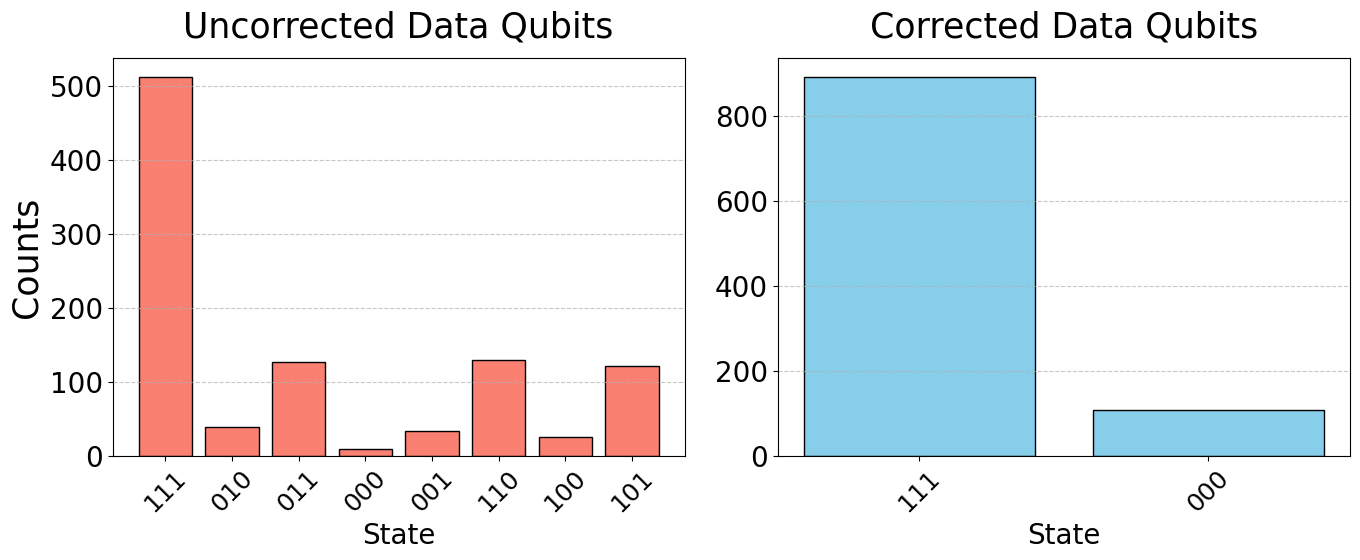

In [19]:
import matplotlib.pyplot as plt
from collections import Counter

print("--- Running 1000-shot simulation ---")
task_visual = device.run(qc, shots=1000)
result_visual = task_visual.result()

raw_counts = Counter()
corrected_counts = Counter()

for bitstring in result_visual.measurements:
    bitstring_list = list(bitstring)
    data_bits = bitstring_list[0:3]
    syn_z = bitstring_list[3:5]

    raw_str = f"{data_bits[0]}{data_bits[1]}{data_bits[2]}"
    raw_counts[raw_str] += 1

    corrected = list(data_bits)
    if syn_z == [1, 0]: corrected[0] ^= 1
    elif syn_z == [0, 1]: corrected[2] ^= 1
    elif syn_z == [1, 1]: corrected[1] ^= 1

    corr_str = f"{corrected[0]}{corrected[1]}{corrected[2]}"
    corrected_counts[corr_str] += 1

# ==========================================================

plt.rcParams.update({'font.size': 20})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(raw_counts.keys(), raw_counts.values(), color='salmon', edgecolor='black')
ax1.set_title('Uncorrected Data Qubits', fontsize=25, pad=15) 
ax1.set_xlabel('State', fontsize=20) 
ax1.set_ylabel('Counts', fontsize=25) 
ax1.tick_params(axis='x', rotation=45, labelsize=18) 
ax1.tick_params(axis='y', labelsize=20)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.bar(corrected_counts.keys(), corrected_counts.values(), color='skyblue', edgecolor='black')
ax2.set_title('Corrected Data Qubits', fontsize=25, pad=15) 
ax2.set_xlabel('State', fontsize=20) 
ax2.tick_params(axis='x', rotation=45, labelsize=18) 
ax2.tick_params(axis='y', labelsize=20)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

## 4. Full Integration: Complete Shor 9-Qubit Code Circuit

We now combine the bit-flip and phase-flip protection mechanisms to implement the complete Shor 9-qubit quantum error-correcting code using the Amazon Braket SDK.

### 4.1 State Preparation & Concatenated Encoding

The Shor code employs a **concatenated code** architecture: an outer encoding layer protects against phase-flips, while an inner encoding layer protects against bit-flips.

<div class="alert alert-block alert-success">
<b>Activity: Choose the logical input state before Shor encoding</b>

Run the next cell with `LOGICAL_INPUT = "1"`, then change it to `"0"` and run again. The only difference should be whether the initial `X` gate is added to qubit 0 before encoding. This cell is safe to run locally because it only builds the circuit and prints the Braket circuit diagram.
</div>


In [ ]:
from braket.circuits import Circuit
from braket.devices import LocalSimulator

# Initialize circuit: 9 data qubits (d0-d8) and 8 ancilla qubits (a0-a7, i.e., q9-q16)
qc = Circuit()

# Choose the logical input state before encoding.
# X: changes |0> into |1>.
LOGICAL_INPUT = "1"  # choose "0" or "1"
if LOGICAL_INPUT == "1":
    qc.x(0)
elif LOGICAL_INPUT != "0":
    raise ValueError("LOGICAL_INPUT must be '0' or '1'")

# (A) Outer encoding: Phase-flip protection
qc.cnot(0, 3).cnot(0, 6)
qc.h([0, 3, 6])

# (B) Inner encoding: Bit-flip protection
qc.cnot(0, 1).cnot(0, 2)   # Block 1: q0, q1, q2
qc.cnot(3, 4).cnot(3, 5)   # Block 2: q3, q4, q5
qc.cnot(6, 7).cnot(6, 8)   # Block 3: q6, q7, q8

print(qc)


### 4.2 Error Injection (for Noiseless Simulator)

To verify the Shor code's full fault-tolerance capability, we inject the most destructive **Pauli-$Y$ error**. The $Y$ error is equivalent to simultaneous $X$ and $Z$ errors (with an imaginary phase factor), triggering both defense layers simultaneously.

In [ ]:
# Inject a Pauli-Y error on d0 (simultaneous bit-flip and phase-flip)
qc.y(0)

### 4.3 Syndrome Extraction: 8 Stabilizer Measurements

Eight ancilla qubits are used to read the system's error syndrome without disturbing the data qubits' quantum state.

In [ ]:
ancillas = range(9, 17)
qc.h(ancillas)  # Initialize ancilla qubits to X-basis (|+> state)

# [First defense layer] Z-type stabilizers: detect X errors (bit-flips)
qc.cz(9, 0).cz(9, 1)     # g1 = Z0Z1 (Block 1)
qc.cz(10, 1).cz(10, 2)   # g2 = Z1Z2
qc.cz(11, 3).cz(11, 4)   # g3 = Z3Z4 (Block 2)
qc.cz(12, 4).cz(12, 5)   # g4 = Z4Z5
qc.cz(13, 6).cz(13, 7)   # g5 = Z6Z7 (Block 3)
qc.cz(14, 7).cz(14, 8)   # g6 = Z7Z8

# [Second defense layer] X-type stabilizers: detect Z errors (phase-flips)
qc.cnot(15, 0).cnot(15, 1).cnot(15, 2)
qc.cnot(15, 3).cnot(15, 4).cnot(15, 5)   # g7 = X0..X5 (Block 1 vs 2)

qc.cnot(16, 3).cnot(16, 4).cnot(16, 5)
qc.cnot(16, 6).cnot(16, 7).cnot(16, 8)   # g8 = X3..X8 (Block 2 vs 3)

qc.h(ancillas)  # Rotate ancilla qubits back to Z-basis for measurement

### 4.4 Worked Example: Shor Code Circuit Execution
The Shor-code and surface-code functions are stored in the `helper_functions/` folder, instead of being written repeatedly inside this notebook. This keeps the tutorial focused on the main ideas while the implementation details stay organized in separate `.py` files.

Because Jupyter notebooks may be launched from different working directories, we use `find_helper_functions_dir()` to automatically search upward from the current kernel folder until it finds the correct `helper_functions/` directory. After the folder is found, its path is added to 
`sys.path`, so Python can import functions such as `shor_code_functions.py`, `surface_code_hpc.py`, `sweep_config.py`, and `aggregate.py`.

> **Note**: The full Shor code requires 17 qubits (9 data + 8 ancilla), which exceeds the dimension limit of Braket's local density matrix simulator (`numpy` arrays support a maximum of 32 dimensions, corresponding to 16 qubits). We therefore use the AWS cloud-based `DM1` simulator with a global `NoiseModel`.

In [ ]:
import os
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from braket.aws import AwsDevice
from braket.tracking import Tracker


def find_helper_functions_dir(start: Path = Path.cwd()) -> Path:
    """Find the helper_functions folder from the notebook or current kernel folder."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        helper_dir = candidate / "helper_functions"
        if (helper_dir / "shor_code_functions.py").exists():
            return helper_dir
        if candidate.name == "helper_functions" and (candidate / "shor_code_functions.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find helper_functions/shor_code_functions.py. "
        "Place Notebook 4 outside the helper_functions folder, with helper_functions next to it."
    )


HELPER_DIR = find_helper_functions_dir()
PROJECT_DIR = HELPER_DIR.parent
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))
os.chdir(PROJECT_DIR)

from shor_code_functions import (
    build_full_shor_qec_circuit,
    build_shor_noise_model,
    build_shor_syndrome_circuit,
    build_shor_x_error_demo_circuit,
    decode_batch_counts,
    decode_x_error_counts,
    format_task_report,
    plot_full_qec_summary,
    plot_raw_corrected_counts,
    score_full_qec_counts,
)

print(f"project_dir: {PROJECT_DIR}")
print(f"helper_dir : {HELPER_DIR}")


In [16]:
# ==========================================
# --- 0. Start Resource Tracker ---
# ==========================================
tracker = Tracker().start()

<div class="alert alert-block alert-success">
<b>Activity: Build the packaged Shor circuit</b>

Run the next cell to see how the helper function builds the 17-qubit Shor circuit. Try changing `LOGICAL_INPUT` between `"0"` and `"1"`. This cell only constructs the circuit and does not submit anything to AWS.
</div>


In [ ]:
# ==========================================
# --- 1. Build the Shor 17-Qubit Circuit ---
# ==========================================
LOGICAL_INPUT = "1"  # choose "0" or "1"

# The circuit details are packaged in shor_code_functions.py so the notebook stays readable.
qc_shor = build_shor_syndrome_circuit(logical_input=LOGICAL_INPUT)

print(qc_shor)


<div class="alert alert-block alert-success">
<b>Activity: Optional DM1 execution, cost and timing</b>

Run the next cell only if your AWS Braket credentials are configured. Keep `RUN_DEMO_DM1 = False` while reading the notebook; in that case the circuit and noise model are prepared, but no AWS task is submitted. Set `RUN_DEMO_DM1 = True` only when you intentionally want to run DM1. Once the DM1 result is returned, the following decoding and plot cells will show the corrected distribution; otherwise the state is still only an uncorrected circuit description and no corrected measurement result exists yet.
</div>


In [ ]:
# ==========================================
# --- 2. Build Global Noise Model ---
# ==========================================
p_error = 0.10
shor_noise_model = build_shor_noise_model(p_error=p_error)

# ==========================================
# --- 3. Optional Submit Task to AWS DM1 Cloud Simulator ---
# ==========================================
RUN_DEMO_DM1 = False
SHOR_DM1_SHOTS = 1000

# These variables are used by the following decoding/plot cells.
shor_dm1_result = None
raw_counts = None
corrected_counts = None

if RUN_DEMO_DM1:
    device = AwsDevice(
        "arn:aws:braket:::device/quantum-simulator/amazon/dm1",
        noise_model=shor_noise_model,
    )

    print(f"--- Submitting {SHOR_DM1_SHOTS}-shot task to AWS DM1 ---")
    submit_t0 = time.perf_counter()
    task = device.run(qc_shor, shots=SHOR_DM1_SHOTS)

    print(f"Task ARN: {task.id}")
    print(f"Status: {task.state()}")

    shor_dm1_result = task.result()
    notebook_wall_sec = time.perf_counter() - submit_t0
    print(f"Task completed! Final status: {task.state()}")

    # ==========================================
    # --- 4. Cost and Time Report ---
    # ==========================================
    print(format_task_report(shor_dm1_result, tracker=tracker, notebook_wall_sec=notebook_wall_sec))
else:
    print("RUN_DEMO_DM1 is False, so no AWS DM1 task was submitted.")
    print("The next decoding/plot cells need a completed DM1 result before corrected states can be shown.")


### 4.5 Simulation and Classical Decoding

The ancilla measurement results are fed into a classical **lookup table** to locate and correct errors. This step requires actual measurement counts from DM1. If `RUN_DEMO_DM1 = False`, there is no `shor_dm1_result` yet, so the notebook cannot display a corrected state distribution. In that case, the circuit is built but the measurement state should still be interpreted as **not yet corrected by simulation output**.


In [ ]:
# ==========================================
# --- 5. Classical Decoding (Batch Processing) ---
# ==========================================
if shor_dm1_result is None:
    print("No DM1 result is available because RUN_DEMO_DM1 is False.")
    print("Set RUN_DEMO_DM1 = True in the previous cell, wait for the task result, then rerun this decoding cell.")
else:
    print("--- Performing classical decoding ---")
    raw_counts, corrected_counts = decode_batch_counts(shor_dm1_result.measurement_counts)

    print(f"Unique raw states observed: {len(raw_counts)}")
    print(f"Unique corrected states:    {len(corrected_counts)}")


<div class="alert alert-block alert-success">
<b>Activity: Plot corrected Shor state after DM1 result is available</b>

Run the next cell after the DM1 execution and decoding cells have produced `raw_counts` and `corrected_counts`. If `RUN_DEMO_DM1 = False`, the plot is skipped because no measurement result has been decoded yet. Once the DM1 result exists, the right panel shows the classically corrected distribution; before that point, the circuit state has not been corrected in the plotted data.
</div>


In [ ]:
if raw_counts is None or corrected_counts is None:
    print("No decoded DM1 counts are available yet, so the corrected-state plot is skipped.")
    print("Set RUN_DEMO_DM1 = True in the DM1 execution cell, then rerun decoding and plotting.")
else:
    fig = plot_raw_corrected_counts(raw_counts, corrected_counts, title_prefix="Shor DM1: ")
    plt.show()


### Complete Executable Code: Shor Code Simulation Using DM1

The complete runnable version is packaged as `helper_functions/run_shor_dm1_demo.py`. The notebook should show the workflow and interpretation; the `.py` file should hold the full executable code so users can run the same experiment from a terminal or cluster environment.


Recommended command-line usage:

```bash
# X-error-only Shor demo
python3 helper_functions/run_shor_dm1_demo.py --mode x-only --logical-input 1 --shots 1000 --p-error 0.03

# Full X/Z Shor QEC demo
python3 helper_functions/run_shor_dm1_demo.py --mode full --shots 4000 --p-x 0.02 --p-z 0.02
```

Adjustable parameters:

- `--mode`: choose `x-only` for the compact bit-flip-focused demo, or `full` for the X/Z syndrome demo.
- `--logical-input`: choose `0` or `1` for the initial logical state in `x-only` mode.
- `--shots`: number of measurement shots.
- `--p-error`: bit-flip probability in `x-only` mode.
- `--p-x`, `--p-z`: bit-flip and phase-flip probabilities in `full` mode.
- `--no-plot`: run without plotting, useful on a cluster or SSH session.


<div class="alert alert-block alert-success">
<b>Activity: x-only Shor demo</b>

This cell prepares the packaged X-error-correction demo. With `RUN_DEMO_DM1 = False`, it only builds the circuit and prints the configuration; no AWS task is submitted and no corrected distribution is available. Set `RUN_DEMO_DM1 = True` to submit to DM1. Once the DM1 result returns, the cell decodes the counts and plots raw vs corrected states.
</div>


In [ ]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from braket.aws import AwsDevice
from braket.tracking import Tracker

RUN_DEMO_DM1 = False

HELPER_DIR = next(
    candidate / "helper_functions"
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / "helper_functions" / "shor_code_functions.py").exists()
)
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))
os.chdir(HELPER_DIR.parent)

from shor_code_functions import build_shor_x_error_demo_circuit, decode_x_error_counts, plot_raw_corrected_counts

# =============================================================
# Shor 9-qubit code demo -- X-error correction only
# =============================================================
P_ERROR = 0.03
SHOTS = 1000
LOGICAL_INPUT = "1"

qc = build_shor_x_error_demo_circuit(logical_input=LOGICAL_INPUT, p_error=P_ERROR)

print("Built Shor X-error demo circuit.")
print(f"logical input: {LOGICAL_INPUT}")
print(f"p_error      : {P_ERROR}")
print(f"shots        : {SHOTS}")

if RUN_DEMO_DM1:
    tracker = Tracker().start()
    device = AwsDevice("arn:aws:braket:::device/quantum-simulator/amazon/dm1")

    print("Submitting to DM1 ...")
    task = device.run(qc, shots=SHOTS)
    print(f"Task ARN: {task.id}")
    result = task.result()
    print(f"Status: {task.state()}")
    print(f"Estimated cost: ${tracker.simulator_tasks_cost():.4f} USD")

    decoded = decode_x_error_counts(result.measurement_counts, logical_input=LOGICAL_INPUT)
    print(f"=== Logical recovery rate (data == '{decoded['expected_data']}') ===")
    print(f"  Raw       : {decoded['raw_success']}/{decoded['total']} = {decoded['raw_rate']:.3f}")
    print(f"  Corrected : {decoded['corrected_success']}/{decoded['total']} = {decoded['corrected_rate']:.3f}")

    plot_raw_corrected_counts(decoded["raw_counts"], decoded["corrected_counts"])
    plt.show()
else:
    print("RUN_DEMO_DM1 is False, so no AWS DM1 task was submitted.")
    print("No corrected distribution is available until the DM1 result is returned and decoded.")


<div class="alert alert-block alert-success">
<b>Activity: full X/Z Shor QEC demo</b>

This cell prepares the full X/Z Shor QEC demo. With `RUN_DEMO_DM1 = False`, it only prints the configuration; no AWS task is submitted and no corrected fidelity plot is available. Set `RUN_DEMO_DM1 = True` to submit two DM1 tasks. Once the results return, the cell scores raw vs corrected fidelity and plots the corrected summary.
</div>


In [ ]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from braket.aws import AwsDevice
from braket.tracking import Tracker

RUN_DEMO_DM1 = False

HELPER_DIR = next(
    candidate / "helper_functions"
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / "helper_functions" / "shor_code_functions.py").exists()
)
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))
os.chdir(HELPER_DIR.parent)

from shor_code_functions import build_full_shor_qec_circuit, plot_full_qec_summary, score_full_qec_counts

# =================================================================
# Full Shor 9-qubit QEC demo
# =================================================================
P_X, P_Z = 0.02, 0.02
SHOTS = 4000

print("Full Shor 9-qubit QEC demo configuration:")
print(f"  P_X   : {P_X}")
print(f"  P_Z   : {P_Z}")
print(f"  shots : {SHOTS}")
print("This demo submits two DM1 tasks when RUN_DEMO_DM1 is True.")

if RUN_DEMO_DM1:
    device = AwsDevice("arn:aws:braket:::device/quantum-simulator/amazon/dm1")
    tracker = Tracker().start()

    results = {}
    for basis, expected in [("X", 0), ("Z", 0)]:
        label = "|+>_L (Testing X-error correction)" if basis == "X" else "|0>_L (Testing Z-error correction)"
        print(f"=== Test {basis}: {label} ===")
        task = device.run(build_full_shor_qec_circuit(basis, p_x=P_X, p_z=P_Z), shots=SHOTS)
        print(f"Task ARN : {task.id}")
        result = task.result()
        print(f"Status   : {task.state()}")

        score = score_full_qec_counts(result.measurement_counts, basis=basis, expected=expected)
        results[basis] = (score["raw_fidelity"], score["corrected_fidelity"])
        print(f"  Raw  fidelity : {score['raw_fidelity']:.4f}")
        print(f"  Corr fidelity : {score['corrected_fidelity']:.4f}")

    print(f"Estimated cost: ${tracker.simulator_tasks_cost():.4f} USD")
    plot_full_qec_summary(results, p_x=P_X, p_z=P_Z)
    plt.show()
else:
    print("RUN_DEMO_DM1 is False, so no AWS DM1 task was submitted.")
    print("No corrected fidelity plot is available until the DM1 results are returned and scored.")


#### Interpreting the Results

In the Shor 9-qubit code encoding design, the 9 data qubits are divided into **3 independent protection blocks** (q0–2, q3–5, q6–8). Because Hadamard gates are applied during encoding, each block is actually in a $\frac{|000\rangle \pm |111\rangle}{\sqrt{2}}$ superposition state before the final measurement. When the circuit completes and measurement occurs, the quantum state collapses: each block has a 50% probability of yielding `000` and a 50% probability of yielding `111`. With 3 blocks, this produces $2^3 = 8$ possible combinations:

- `000 000 000`, `000 000 111`, `000 111 000`, `000 111 111`
- `111 000 000`, `111 000 111`, `111 111 000`, `111 111 111`

This explains why the corrected bar chart shows these 8 valid states with approximately equal distribution, while other erroneous states are greatly reduced or eliminated.

---

## 5. From Shor Code to Surface Code

Shor code is a useful conceptual bridge because it shows how bit-flip and phase-flip protection can be combined into one logical qubit. Surface code keeps the same stabilizer idea, but changes the architecture: checks are local on a 2D nearest-neighbor layout, and protection improves by increasing the code distance `d`.

The production surface-code functions are already in three Python files inside the `helper_functions/` folder:

- `helper_functions/surface_code_hpc.py`: builds one noisy rotated surface-code memory circuit and runs one Monte Carlo replica.
- `helper_functions/sweep_config.py`: defines the threshold-sweep grid: distances, physical error rates, replicas, shots, and seeds.
- `helper_functions/aggregate.py`: aggregates replica JSON files, computes Wilson confidence intervals, and plots threshold curves.

This notebook introduces the concepts, calls the important functions, and teaches how to measure timing so AWS `EC2` and `PCS` runs can be compared.


In [ ]:
# Run once if the current environment does not already have the surface-code stack.
# %pip install --only-binary=:all: stim pymatching

In [ ]:
import concurrent.futures as cf
import json
import os
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REQUIRED_HELPER_FILES = (
    "sweep_config.py",
    "surface_code_hpc.py",
    "aggregate.py",
    "surface_code_timing.py",
    "timing_report.py",
)


def find_surface_helper_dir(start: Path = Path.cwd()) -> Path:
    """Find helper_functions containing the surface-code helper .py files."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        helper_dir = candidate / "helper_functions"
        if all((helper_dir / name).exists() for name in REQUIRED_HELPER_FILES):
            return helper_dir
        if candidate.name == "helper_functions" and all((candidate / name).exists() for name in REQUIRED_HELPER_FILES):
            return candidate
    raise FileNotFoundError(
        "Could not find helper_functions with sweep_config.py, surface_code_hpc.py, "
        "aggregate.py, surface_code_timing.py, and timing_report.py."
    )


HELPER_DIR = find_surface_helper_dir()
PROJECT_DIR = HELPER_DIR.parent
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))
os.chdir(PROJECT_DIR)

import aggregate
import sweep_config
from aggregate import wilson_ci
from surface_code_hpc import build_circuit, count_active_qubits, run_replica
from surface_code_timing import (
    compare_timing_summaries,
    describe_sweep,
    format_timing_comparison,
    load_replica_records,
    load_timing_summary,
    make_timing_summary_from_replica_json,
    save_timing_summary,
    summarize_timing,
)
from timing_report import create_report

BASE_DIR = PROJECT_DIR
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"project_dir: {PROJECT_DIR}")
print(f"helper_dir : {HELPER_DIR}")
print(f"kernel cwd : {Path.cwd()}")
print(f"default sweep tasks: {len(sweep_config.grid())}")
print(f"shots per replica: {sweep_config.SHOTS_PER_REPLICA:,}")


### 5.1 Minimal Surface-Code Concepts

For a rotated surface code:

```text
data qubits            = d^2
ancilla/check qubits   = d^2 - 1
active physical qubits = 2d^2 - 1
```

Important terms:

- `distance d`: the minimum weight of an undetected logical operator. Increasing `d` usually lowers the logical error rate below threshold, but increases qubit count and decoding cost.
- `round`: one syndrome-extraction cycle. Memory experiments usually use `rounds = d`.
- `syndrome`: one stabilizer-check measurement result.
- `detector event`: a change between neighboring syndrome rounds, often `syndrome[t] XOR syndrome[t-1]`.
- `logical error`: a decoder failure inferred after many physical noise events, not something injected directly.


In [ ]:
def surface_code_size(distance: int) -> dict:
    data = distance * distance
    ancilla = distance * distance - 1
    return {
        "distance": distance,
        "data_qubits": data,
        "ancilla_qubits": ancilla,
        "active_qubits": data + ancilla,
        "rough_detectors_for_rounds_eq_d": ancilla * distance,
    }


for d in [3, 5, 7, 9, 11]:
    print(surface_code_size(d))


In [ ]:
# The real circuit construction lives in surface_code_hpc.py.
# Here we only call it to show the d=3 structure used later in timing experiments.
small_circuit = build_circuit(distance=3, rounds=3, p=0.005)
data_qubits, ancilla_qubits, active_qubits = count_active_qubits(small_circuit)

print(f"data qubits           : {data_qubits}")
print(f"ancilla/check qubits  : {ancilla_qubits}")
print(f"active physical qubits: {active_qubits}")
print(f"Stim qubit label span : {small_circuit.num_qubits}")
print(f"detectors             : {small_circuit.num_detectors}")
print(f"observables           : {small_circuit.num_observables}")


In [ ]:
def detector_events_from_syndromes(syndromes):
    return [None] + [syndromes[t] ^ syndromes[t - 1] for t in range(1, len(syndromes))]


syndrome_history = [0, 0, 1, 1, 0]
print("syndrome history:", syndrome_history)
print("detector events :", detector_events_from_syndromes(syndrome_history))


### 5.2 One Replica: The Most Important Function

A threshold sweep is many independent calls to `run_replica(distance, rounds, p, shots, seed)`. Each call returns one JSON-like record with the logical-error count, detector count, matching graph size, and internal `elapsed_sec` when executed through `surface_code_hpc.py`.

Use a tiny shot count in the notebook for a smoke test. Use PCS for the full sweep.


<div class="alert alert-block alert-success">
<b>Activity: Local surface-code smoke test</b>

Run the next cell to verify that `surface_code_hpc.run_replica()` works before launching a large sweep. Try changing `DEMO_P` or `DEMO_SHOTS`, but keep `DEMO_SHOTS` small in the notebook. Large `shots=100000` sweeps should move to EC2/PCS.
</div>


In [ ]:
DEMO_DISTANCE = 3
DEMO_P = 0.005
DEMO_SHOTS = 2_000
DEMO_SEED = 1234

t0 = time.perf_counter()
demo_record = run_replica(
    distance=DEMO_DISTANCE,
    rounds=DEMO_DISTANCE,
    p=DEMO_P,
    shots=DEMO_SHOTS,
    seed=DEMO_SEED,
)
demo_wall_sec = time.perf_counter() - t0

print(json.dumps({
    "distance": demo_record["distance"],
    "p": demo_record["physical_error_rate"],
    "shots": demo_record["shots"],
    "active_qubits": demo_record["active_qubits"],
    "detectors": demo_record["detectors"],
    "matching_edges": demo_record["matching_edges"],
    "logical_errors": demo_record["logical_errors"],
    "logical_error_rate": demo_record["logical_error_rate"],
    "notebook_wall_sec": demo_wall_sec,
}, indent=2))


### 5.3 Threshold Sweep Timing: EC2 vs PCS

The default sweep in `sweep_config.py` is:

```text
distances = [3, 5, 7, 9]
p values  = 8 points from 0.001 to 0.02
replicas  = 4 per (d, p)
shots     = 100,000 per replica
```

That is `4 * 8 * 4 = 128` independent tasks. The important timing fields are:

- `wall_clock_total_sec`: real elapsed time from launching the sweep until every task finishes.
- `sum_replica_elapsed_sec`: sum of all replica compute times. This can be larger than wall-clock time when tasks run in parallel.
- `aggregate_elapsed_sec`: time spent aggregating JSON records into CSV/plots/timing summaries.
- `timing_by_distance`: runtime grouped by distance, useful because high-distance tasks usually dominate.

In this notebook, EC2/notebook execution and PCS execution are separated:

- **5.3A** runs the surface-code sweep directly from imported Python helper files and produces EC2-style JSON, threshold plot, and timing chart.
- **5.3B** only documents the PCS/Slurm commands used on the cluster.
- **5.4** reads completed EC2 and PCS JSON folders and produces comparison charts.


In [ ]:
full_sweep = describe_sweep(
    sweep_config.DISTANCES,
    sweep_config.P_VALUES,
    sweep_config.REPLICAS_PER_POINT,
    sweep_config.SHOTS_PER_REPLICA,
)
print(json.dumps(full_sweep, indent=2))

### 5.3A EC2/Notebook Direct Sweep from Imported Helper Files

This section uses the helper files directly from Python imports. There is no `.sh` file, no Slurm array, and no PCS command here.

Imported helper files used in this workflow:

- `helper_functions/sweep_config.py`: defines the sweep grid.
- `helper_functions/surface_code_hpc.py`: provides `run_replica()` for one Monte Carlo task.
- `helper_functions/aggregate.py`: provides the threshold aggregation logic and Wilson confidence interval convention.
- `helper_functions/surface_code_timing.py`: summarizes wall-clock and per-distance timing.
- `helper_functions/timing_report.py`: writes the report CSV files and threshold curve.

The code cell below is guarded by `RUN_EC2_THRESHOLD_SWEEP`. Leave it `False` while teaching or reading the notebook. Set it to `True` only when you intentionally want to run the EC2/notebook calculation.


<div class="alert alert-block alert-success">
<b>Activity: Run EC2/notebook sweep and generate EC2 plots</b>

Run the next cell once with `RUN_EC2_THRESHOLD_SWEEP = False` to inspect the configuration. When you are ready to calculate, set it to `True`. The cell writes one JSON result per task, saves a timing summary, creates a threshold curve, and creates a timing-by-distance chart.
</div>


In [ ]:
# True means: start the EC2/notebook calculation.
# False means: only print the configuration and output paths.
RUN_EC2_THRESHOLD_SWEEP = False

# EC2/notebook sweep configuration. By default this mirrors sweep_config.py.
EC2_SWEEP_DISTANCES = sweep_config.DISTANCES
EC2_SWEEP_P_VALUES = sweep_config.P_VALUES
EC2_SWEEP_REPLICAS = sweep_config.REPLICAS_PER_POINT
EC2_SWEEP_SHOTS_PER_REPLICA = sweep_config.SHOTS_PER_REPLICA
EC2_MAX_WORKERS = min(2, os.cpu_count() or 1)

# Results are written to the EC2 results folder using a run-specific prefix.
# If you rerun the sweep, keep this prefix or folder in mind when comparing results later.
EC2_RUN_ID = time.strftime("%Y%m%d_%H%M%S")
EC2_RESULTS_DIR = PROJECT_DIR / "results"
EC2_OUTPUT_PREFIX = f"threshold_ec2_{EC2_RUN_ID}"
EC2_SUMMARY_PATH = EC2_RESULTS_DIR / f"run_summary_ec2_{EC2_RUN_ID}.json"
TIMING_REPORTS_DIR = PROJECT_DIR / "timing_reports"
TIMING_REPORTS_DIR.mkdir(exist_ok=True)

print("Imported helper files:")
print(f"  sweep_config       : {Path(sweep_config.__file__)}")
print(f"  surface_code_hpc   : {HELPER_DIR / 'surface_code_hpc.py'}")
print(f"  aggregate          : {Path(aggregate.__file__)}")
print(f"  surface_code_timing: {HELPER_DIR / 'surface_code_timing.py'}")
print(f"  timing_report      : {HELPER_DIR / 'timing_report.py'}")

sweep_info = describe_sweep(
    EC2_SWEEP_DISTANCES,
    EC2_SWEEP_P_VALUES,
    EC2_SWEEP_REPLICAS,
    EC2_SWEEP_SHOTS_PER_REPLICA,
)
print()
print("EC2/notebook sweep configuration:")
print(json.dumps({**sweep_info, "max_workers": EC2_MAX_WORKERS}, indent=2))
print(f"result folder : {EC2_RESULTS_DIR}")
print(f"result prefix : {EC2_OUTPUT_PREFIX}")
print(f"summary JSON  : {EC2_SUMMARY_PATH}")


def build_ec2_tasks():
    tasks = []
    idx = 0
    for distance in EC2_SWEEP_DISTANCES:
        for p in EC2_SWEEP_P_VALUES:
            for replica in range(EC2_SWEEP_REPLICAS):
                seed = (idx * 1_000_003 + 54321) % (2**31 - 1)
                tasks.append({
                    "task_idx": idx,
                    "distance": int(distance),
                    "p": float(p),
                    "replica": int(replica),
                    "seed": int(seed),
                    "shots": int(EC2_SWEEP_SHOTS_PER_REPLICA),
                })
                idx += 1
    return tasks


def run_one_ec2_task(task):
    t0 = time.perf_counter()
    record = run_replica(
        distance=task["distance"],
        rounds=task["distance"],
        p=task["p"],
        shots=task["shots"],
        seed=task["seed"],
    )
    record.update({
        "replica": task["replica"],
        "task_idx": task["task_idx"],
        "elapsed_sec": time.perf_counter() - t0,
        "host": platform.node(),
        "execution_environment": "ec2_notebook",
    })
    return record


def save_replica_json(record):
    out = EC2_RESULTS_DIR / f"{EC2_OUTPUT_PREFIX}_{record['task_idx']}.json"
    with open(out, "w") as f:
        json.dump(record, f, indent=2)
    return out


def plot_ec2_distance_timing(timing_by_distance, path):
    distances = [item["distance"] for item in timing_by_distance]
    sums = [item["sum_replica_elapsed_sec"] for item in timing_by_distance]
    means = [item["mean_replica_elapsed_sec"] for item in timing_by_distance]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].bar([str(d) for d in distances], sums, color="#4C78A8")
    axes[0].set_xlabel("distance d")
    axes[0].set_ylabel("seconds")
    axes[0].set_title("EC2 sum replica time by distance")
    axes[0].grid(axis="y", linestyle="--", alpha=0.35)

    axes[1].bar([str(d) for d in distances], means, color="#59A14F")
    axes[1].set_xlabel("distance d")
    axes[1].set_ylabel("seconds")
    axes[1].set_title("EC2 mean replica time by distance")
    axes[1].grid(axis="y", linestyle="--", alpha=0.35)

    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()
    return path


if RUN_EC2_THRESHOLD_SWEEP:
    EC2_RESULTS_DIR.mkdir(exist_ok=True)
    ec2_tasks = build_ec2_tasks()
    records = []
    sweep_t0 = time.perf_counter()

    with cf.ThreadPoolExecutor(max_workers=EC2_MAX_WORKERS) as executor:
        futures = [executor.submit(run_one_ec2_task, task) for task in ec2_tasks]
        for future in cf.as_completed(futures):
            record = future.result()
            records.append(record)
            output_path = save_replica_json(record)
            print(f"[{len(records):>3}/{len(ec2_tasks)}] saved {output_path.name}")

    wall_clock_total_sec = time.perf_counter() - sweep_t0
    aggregate_t0 = time.perf_counter()
    ec2_timing_summary = summarize_timing(
        records,
        wall_clock_total_sec=wall_clock_total_sec,
        label="ec2",
        max_workers=EC2_MAX_WORKERS,
        host=platform.node(),
    )
    ec2_timing_summary["aggregate_elapsed_sec"] = time.perf_counter() - aggregate_t0
    save_timing_summary(ec2_timing_summary, EC2_SUMMARY_PATH)

    report_result = create_report(
        results_dir=EC2_RESULTS_DIR,
        output_dir=TIMING_REPORTS_DIR,
        label="ec2",
        prefix=EC2_OUTPUT_PREFIX,
        wall_clock_total_sec=wall_clock_total_sec,
    )
    ec2_distance_chart_path = TIMING_REPORTS_DIR / "ec2_distance_timing.png"
    plot_ec2_distance_timing(ec2_timing_summary["timing_by_distance"], ec2_distance_chart_path)

    print(report_result["report"])
    print(f"Saved EC2 threshold chart: {report_result['chart_path']}")
    print(f"Saved EC2 timing chart   : {ec2_distance_chart_path}")
    print(f"Saved EC2 summary JSON   : {EC2_SUMMARY_PATH}")
else:
    print()
    print("RUN_EC2_THRESHOLD_SWEEP is False, so no calculation was started.")
    print("Set RUN_EC2_THRESHOLD_SWEEP = True to run the EC2/notebook sweep.")


### 5.3B PCS Process: Run the Same Sweep on the Cluster

The notebook does not execute PCS or Slurm commands. Use this section as the cluster-side checklist after uploading `run_threshold_sweep.sh` and the `helper_functions/` folder to the PCS project folder.


<div class="alert alert-block alert-success">
<b>Activity: PCS full sweep commands and wall-clock timing</b>

Use this activity after uploading `run_threshold_sweep.sh` and the `helper_functions/` folder to the PCS cluster. The `.sh` file runs `surface_code_hpc.py` once per Slurm array task. After all tasks finish, aggregate the JSON files and read the true wall-clock time from Slurm.
</div>


In [ ]:
# These are commands to run on the PCS cluster, from your error_correction project folder.
# This notebook cell only prints the commands; it does not submit a PCS job.

PCS_COMMANDS = f"""
# 1. Go to the project folder on PCS.
cd /shared/error_correction

# 2. Confirm the required files are present.
ls run_threshold_sweep.sh helper_functions/sweep_config.py helper_functions/surface_code_hpc.py helper_functions/aggregate.py

# 3. Confirm the full sweep size. This should print 128 for the default setup.
python3 helper_functions/sweep_config.py --total
python3 helper_functions/sweep_config.py --shots

# 4. Submit the Slurm array job. Save the printed job id.
sbatch run_threshold_sweep.sh

# 5. Watch progress. Replace <JOB_ID> with the number printed by sbatch.
squeue -j <JOB_ID>

# 6. After completion, check whether every task produced a JSON file.
ls threshold_<JOB_ID>_*.json | wc -l

# 7. Aggregate threshold JSON files into CSV and plot.
python3 helper_functions/aggregate.py --results-dir . --prefix threshold --csv threshold_summary.csv --plot threshold_curve.png

# 8. Get true PCS wall-clock time in seconds. Use ElapsedRaw in the timing comparison cell.
sacct -j <JOB_ID> --format=JobID,State,Elapsed,ElapsedRaw,Start,End
"""

print(PCS_COMMANDS)
print("Important timing fields:")
print("  threshold_<JOB_ID>_<TASK_ID>.json -> per-task elapsed_sec")
print("  sacct ElapsedRaw -> true PCS wall_clock_total_sec")
print("  aggregate.py runtime -> aggregation/post-processing time")


### 5.4 Compare Completed EC2 and PCS JSON Results

Use this section after both runs are complete and their replica JSON files have been copied into local result folders. The default convention is:

```text
results/      -> EC2 threshold_*.json files
results_pcs/  -> PCS threshold_*.json files
```

For a fair timing comparison, both folders should contain the same sweep grid, usually `128` files for the default setup. If you have several runs in one folder, narrow the glob pattern to one run prefix, such as `threshold_ec2_20260608_*.json`.


<div class="alert alert-block alert-success">
<b>Activity: Read completed EC2/PCS JSON files and create comparison charts</b>

Run the next cell after EC2 and PCS result JSON files are available locally. Fill in `PCS_WALL_CLOCK_TOTAL_SEC` from Slurm `sacct ElapsedRaw` for true PCS wall-clock timing. If it is left as `None`, the cell uses the sum of per-replica `elapsed_sec` as a placeholder and prints a warning.
</div>


In [ ]:
EC2_RESULT_GLOB = PROJECT_DIR / "results" / "threshold*.json"
PCS_RESULT_GLOB = PROJECT_DIR / "results_pcs" / "threshold*.json"

# Optional wall-clock overrides. PCS should come from: sacct -j <JOB_ID> --format=ElapsedRaw
EC2_WALL_CLOCK_TOTAL_SEC = None
PCS_WALL_CLOCK_TOTAL_SEC = None

EC2_MAX_WORKERS = 2
PCS_MAX_WORKERS = 16


def newest_file(pattern: Path):
    files = sorted(pattern.parent.glob(pattern.name), key=lambda p: p.stat().st_mtime)
    return files[-1] if files else None


def matching_wall_clock_from_summary(summary_path, expected_tasks):
    if summary_path is None:
        return None
    summary = load_timing_summary(summary_path)
    if summary.get("total_tasks") != expected_tasks:
        print(f"WARNING: {summary_path.name} has total_tasks={summary.get('total_tasks')}, but result JSON count is {expected_tasks}.")
        print("The notebook will not reuse that wall-clock value automatically.")
        return None
    return summary.get("wall_clock_total_sec")


def build_summary_from_result_json(result_glob, label, wall_clock_total_sec=None, max_workers=None):
    records = load_replica_records(result_glob)
    wall_clock_is_placeholder = wall_clock_total_sec is None
    if wall_clock_is_placeholder:
        wall_clock_total_sec = sum(float(record.get("elapsed_sec", 0.0)) for record in records)
    summary = summarize_timing(
        records,
        wall_clock_total_sec=wall_clock_total_sec,
        label=label,
        max_workers=max_workers,
    )
    summary["result_glob"] = str(result_glob)
    summary["wall_clock_is_placeholder"] = wall_clock_is_placeholder
    return summary


def plot_timing_comparison(comparison, path):
    labels = [row["label"] for row in comparison["rows"]]
    wall = np.array([row["wall_clock_sec"] for row in comparison["rows"]], dtype=float)
    replica_sum = np.array([row["sum_replica_sec"] for row in comparison["rows"]], dtype=float)
    aggregate = np.array([row["aggregate_sec"] for row in comparison["rows"]], dtype=float)
    parallelism = np.array([row["parallelism_proxy"] for row in comparison["rows"]], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(labels))
    width = 0.25
    axes[0].bar(x - width, wall, width, label="wall-clock")
    axes[0].bar(x, replica_sum, width, label="sum replica")
    axes[0].bar(x + width, aggregate, width, label="aggregate")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel("seconds")
    axes[0].set_title("EC2 vs PCS timing")
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)
    axes[0].legend()

    axes[1].bar(labels, parallelism, color=["#4C78A8", "#59A14F"])
    axes[1].set_ylabel("sum_replica / wall_clock")
    axes[1].set_title("Parallelism proxy")
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)

    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()
    return path


def plot_distance_comparison(ec2_summary, pcs_summary, path):
    def by_distance(summary):
        return {item["distance"]: item for item in summary.get("timing_by_distance", [])}

    ec2_by_d = by_distance(ec2_summary)
    pcs_by_d = by_distance(pcs_summary)
    distances = sorted(set(ec2_by_d) | set(pcs_by_d))
    if not distances:
        raise ValueError("No timing_by_distance entries found.")

    ec2_sum = np.array([ec2_by_d.get(d, {}).get("sum_replica_elapsed_sec", 0.0) for d in distances])
    pcs_sum = np.array([pcs_by_d.get(d, {}).get("sum_replica_elapsed_sec", 0.0) for d in distances])
    ec2_mean = np.array([ec2_by_d.get(d, {}).get("mean_replica_elapsed_sec", 0.0) for d in distances])
    pcs_mean = np.array([pcs_by_d.get(d, {}).get("mean_replica_elapsed_sec", 0.0) for d in distances])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(distances))
    width = 0.35
    axes[0].bar(x - width / 2, ec2_sum, width, label="EC2")
    axes[0].bar(x + width / 2, pcs_sum, width, label="PCS")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"d={d}" for d in distances])
    axes[0].set_ylabel("seconds")
    axes[0].set_title("Sum replica time by distance")
    axes[0].grid(axis="y", linestyle="--", alpha=0.35)
    axes[0].legend()

    axes[1].bar(x - width / 2, ec2_mean, width, label="EC2")
    axes[1].bar(x + width / 2, pcs_mean, width, label="PCS")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"d={d}" for d in distances])
    axes[1].set_ylabel("seconds")
    axes[1].set_title("Mean replica time by distance")
    axes[1].grid(axis="y", linestyle="--", alpha=0.35)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.show()
    return path


ec2_records = load_replica_records(EC2_RESULT_GLOB)
pcs_records = load_replica_records(PCS_RESULT_GLOB)

if EC2_WALL_CLOCK_TOTAL_SEC is None:
    EC2_WALL_CLOCK_TOTAL_SEC = matching_wall_clock_from_summary(
        newest_file(PROJECT_DIR / "results" / "run_summary*.json"),
        expected_tasks=len(ec2_records),
    )

ec2_summary = build_summary_from_result_json(
    EC2_RESULT_GLOB,
    label="ec2",
    wall_clock_total_sec=EC2_WALL_CLOCK_TOTAL_SEC,
    max_workers=EC2_MAX_WORKERS,
)
pcs_summary = build_summary_from_result_json(
    PCS_RESULT_GLOB,
    label="pcs",
    wall_clock_total_sec=PCS_WALL_CLOCK_TOTAL_SEC,
    max_workers=PCS_MAX_WORKERS,
)

comparison = compare_timing_summaries(ec2_summary, pcs_summary)
print(f"EC2 tasks: {ec2_summary['total_tasks']}")
print(f"PCS tasks: {pcs_summary['total_tasks']}")
if ec2_summary["total_tasks"] != pcs_summary["total_tasks"]:
    print("WARNING: EC2 and PCS task counts differ. Compare only after both folders contain the same sweep grid.")
if ec2_summary.get("wall_clock_is_placeholder"):
    print("WARNING: EC2 wall_clock_total_sec is a placeholder.")
if pcs_summary.get("wall_clock_is_placeholder"):
    print("WARNING: PCS wall_clock_total_sec is a placeholder. Fill PCS_WALL_CLOCK_TOTAL_SEC from sacct ElapsedRaw.")

print()
print(format_timing_comparison(comparison))

comparison_chart = PROJECT_DIR / "figures" / "timing" / "timing_comparison_ec2_pcs.png"
distance_chart = PROJECT_DIR / "figures" / "timing" / "timing_by_distance_ec2_pcs.png"
plot_timing_comparison(comparison, comparison_chart)
plot_distance_comparison(ec2_summary, pcs_summary, distance_chart)

print(f"Saved timing comparison chart: {comparison_chart}")
print(f"Saved distance timing chart  : {distance_chart}")


## References

- [Amazon Braket Hybrid Jobs Official Introduction](https://aws.amazon.com/tw/blogs/aws/introducing-amazon-braket-hybrid-jobs-set-up-monitor-and-efficiently-run-hybrid-quantum-classical-workloads/)
- [Amazon Braket SDK Documentation](https://amazon-braket-sdk-python.readthedocs.io/)
- [Stim: a fast stabilizer circuit simulator](https://github.com/quantumlib/Stim)
- [PyMatching: minimum-weight perfect matching decoder](https://github.com/oscarhiggott/PyMatching)
- Shor, P. W. (1995). "Scheme for reducing decoherence in quantum computer memory." *Physical Review A*, 52(4), R2493.
